In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
df = pd.read_csv('movies_9000_dataset.csv')

In [3]:
df.head()

,Movie_Name,Release_Date,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,Movie 1,1980-12-05,A group of friends embark on an unforgettable ...,569.63,13238,5.9,ko,Fantasy,https://image.tmdb.org/t/p/w500/sample_poster_...
1,Movie 2,2020-01-10,An action-packed mission to save the world.,611.76,12763,5.0,hi,"Adventure, Action",https://image.tmdb.org/t/p/w500/sample_poster_...
2,Movie 3,2009-03-27,A group of friends embark on an unforgettable ...,465.88,111,2.7,en,Adventure,https://image.tmdb.org/t/p/w500/sample_poster_...
3,Movie 4,1997-09-22,A group of friends embark on an unforgettable ...,192.20,11804,1.6,es,Sci-Fi,https://image.tmdb.org/t/p/w500/sample_poster_...
4,Movie 5,2004-01-10,A mysterious event changes everything for a sm...,131.69,453,6.7,ko,Thriller,https://image.tmdb.org/t/p/w500/sample_poster_...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Movie_Name         9000 non-null   str    
 1   Release_Date       9000 non-null   str    
 2   Overview           9000 non-null   str    
 3   Popularity         9000 non-null   float64
 4   Vote_Count         9000 non-null   int64  
 5   Vote_Average       9000 non-null   float64
 6   Original_Language  9000 non-null   str    
 7   Genre              9000 non-null   str    
 8   Poster_Url         9000 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 632.9 KB


In [5]:
df['Genre'].head()

0              Fantasy
1    Adventure, Action
2            Adventure
3               Sci-Fi
4             Thriller
Name: Genre, dtype: str

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9000.000000,9000.000000,9000.000000
mean,500.562509,10028.150889,5.466233
std,287.973549,5747.417178,2.608547
min,1.180000,11.000000,1.000000
25%,254.035000,5007.250000,3.200000
50%,497.985000,10014.500000,5.400000
75%,753.085000,15030.250000,7.700000
max,999.820000,20000.000000,10.000000


In [8]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[us]


In [9]:
df['Release_Date'] = df['Release_Date'].dt.year

In [10]:
df['Release_Date'].dtypes

dtype('int32')

In [11]:
df.head()

,Movie_Name,Release_Date,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,Movie 1,1980,A group of friends embark on an unforgettable ...,569.63,13238,5.9,ko,Fantasy,https://image.tmdb.org/t/p/w500/sample_poster_...
1,Movie 2,2020,An action-packed mission to save the world.,611.76,12763,5.0,hi,"Adventure, Action",https://image.tmdb.org/t/p/w500/sample_poster_...
2,Movie 3,2009,A group of friends embark on an unforgettable ...,465.88,111,2.7,en,Adventure,https://image.tmdb.org/t/p/w500/sample_poster_...
3,Movie 4,1997,A group of friends embark on an unforgettable ...,192.20,11804,1.6,es,Sci-Fi,https://image.tmdb.org/t/p/w500/sample_poster_...
4,Movie 5,2004,A mysterious event changes everything for a sm...,131.69,453,6.7,ko,Thriller,https://image.tmdb.org/t/p/w500/sample_poster_...


In [12]:
col = ['Overview', 'Original_Language', 'Poster_Url']

In [13]:
df.drop(col, axis = 1, inplace = True)

In [15]:
df.columns

Index(['Movie_Name', 'Release_Date', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Genre'],
      dtype='str')

In [16]:
df.head()

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,5.9,Fantasy
1,Movie 2,2020,611.76,12763,5.0,"Adventure, Action"
2,Movie 3,2009,465.88,111,2.7,Adventure
3,Movie 4,1997,192.20,11804,1.6,Sci-Fi
4,Movie 5,2004,131.69,453,6.7,Thriller


In [17]:
def catigorised_col(df, col, labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max'],
    ]

    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df

In [18]:
labels = ['Non_popular', 'Below_average', 'Average', 'Popular']

catigorised_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['Average', 'Below_average', 'Non_popular', 'Popular', NaN]
Categories (4, str): ['Non_popular' < 'Below_average' < 'Average' < 'Popular']

In [19]:
df.head()

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,Average,Fantasy
1,Movie 2,2020,611.76,12763,Below_average,"Adventure, Action"
2,Movie 3,2009,465.88,111,Non_popular,Adventure
3,Movie 4,1997,192.20,11804,Non_popular,Sci-Fi
4,Movie 5,2004,131.69,453,Average,Thriller


In [21]:
df['Vote_Average'].value_counts()

Vote_Average
Below_average    2244
Non_popular      2243
Average          2237
Popular          2227
Name: count, dtype: int64

In [22]:
df.dropna(inplace = True)

df.isna().sum()

Movie_Name      0
Release_Date    0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [23]:
df.head()

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,Average,Fantasy
1,Movie 2,2020,611.76,12763,Below_average,"Adventure, Action"
2,Movie 3,2009,465.88,111,Non_popular,Adventure
3,Movie 4,1997,192.20,11804,Non_popular,Sci-Fi
4,Movie 5,2004,131.69,453,Average,Thriller


In [26]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop = True)
df.head()

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,Average,Fantasy
1,Movie 2,2020,611.76,12763,Below_average,Adventure
2,Movie 2,2020,611.76,12763,Below_average,Action
3,Movie 3,2009,465.88,111,Non_popular,Adventure
4,Movie 4,1997,192.20,11804,Non_popular,Sci-Fi


# Casting Column into category 

In [29]:
df['Genre'] = df['Genre'].astype('category')

In [30]:
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Drama',
                  'Fantasy', 'Horror', 'Romance', 'Sci-Fi', 'Thriller'],
, ordered=False, categories_dtype=str)

In [31]:
df.nunique()

Movie_Name      8951
Release_Date      44
Popularity      8556
Vote_Count      7189
Vote_Average       4
Genre             10
dtype: int64

# Data Visualization

# What is the most frequent genre of movies on Netflix?

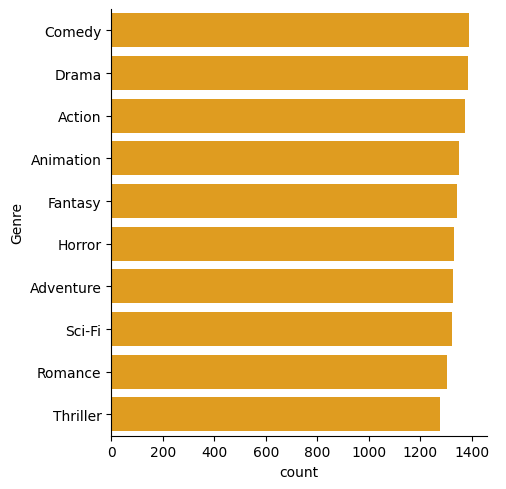

In [36]:
sns.catplot(y = 'Genre', data = df, kind = 'count',
           order = df['Genre'].value_counts().index,
           color = 'orange')

# Which has the highest votes in a votes_average value?

In [37]:
df.head()

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,Average,Fantasy
1,Movie 2,2020,611.76,12763,Below_average,Adventure
2,Movie 2,2020,611.76,12763,Below_average,Action
3,Movie 3,2009,465.88,111,Non_popular,Adventure
4,Movie 4,1997,192.20,11804,Non_popular,Sci-Fi


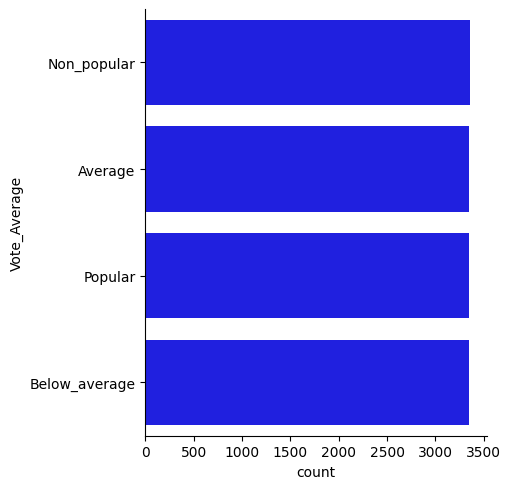

In [48]:
sns.catplot(y = 'Vote_Average', data = df, kind = 'count',
           order = df['Vote_Average'].value_counts().index,
           color = 'blue')

# Which movie got the highest popularity? What is the genre?


In [40]:
df.head(2)

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,Average,Fantasy
1,Movie 2,2020,611.76,12763,Below_average,Adventure


In [42]:
df[df['Popularity'] == df['Popularity'].max()]

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
5819,Movie 3900,1981,999.82,9421,Popular,Drama


# Which movie got the lowest popularity? What is the genre?


In [43]:
df.head(2)

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
0,Movie 1,1980,569.63,13238,Average,Fantasy
1,Movie 2,2020,611.76,12763,Below_average,Adventure


In [44]:
df[df['Popularity'] == df['Popularity'].min()]

,Movie_Name,Release_Date,Popularity,Vote_Count,Vote_Average,Genre
3958,Movie 2641,1998,1.18,50,Popular,Comedy


# Which year has the most filmed movie?

<Axes: >

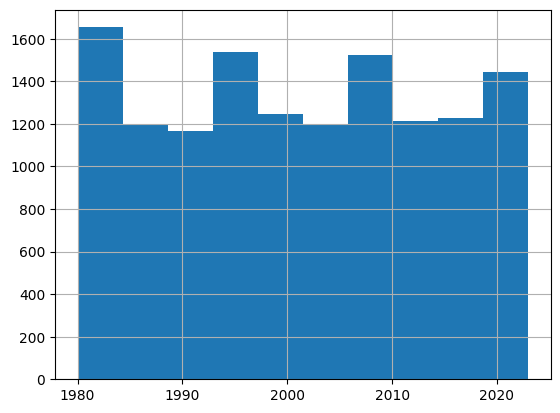

In [45]:
df['Release_Date'].hist()

# Conculsion

Q1- What is the most frequent genre of movies on Netflix?
-> Comedy is the most frequent genre on Netflix.
Q2- Which has the highest votes in a votes_average value?
-> Every categorised value has the same votes.
Q3- Which movie got the highest popularity? What is the genre?
-> Movie 2641 has the highest popularity. Its genre is drama.
Q4- Which movie got the lowest popularity? What is the genre?
-> Movie 2641 has the lowest popularity. Its genre is comedy.
Q5- Which year has the most filmed movies?
-> 1980 is the year that has most movies.